In [1]:
import torch
import torch.nn as nn
from Model import EEGModel
from Data import EEG0012017DataLoader
import matplotlib.pyplot as plt

In [2]:
SUBJECT_COUNT = 15
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
BATCH_SIZE = 10
SPLIT = (0.8, 0.1, 0.1)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CRITERION = nn.CrossEntropyLoss()
MODEL_ARCHITECTURES = ['EEGNet', 'DeepConvNet', 'ShallowFBCSPNet']
LEARNING_RATE = 0.01
EPOCH_NUM = 30
RANDOM_SEED = 42

In [3]:
def plot_learning_curves(train_losses, val_losses, title_exp='Loss'):
    """
    Plots the training and validation loss curves over epochs.
    
    Args:
        train_losses (list of floats): Loss values for the training set per epoch.
        val_losses (list of floats): Loss values for the validation set per epoch.
        save_path (str, optional): If provided, saves the plot to this file path.
    """
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    
    plt.title(f'Training and Validation {title_exp}', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Force x-axis to use integer ticks for epochs
    plt.xticks(epochs) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    plt.show()

In [4]:
data_loader_factory = EEG0012017DataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']



------ Setting up training for Subject 1 ------
Preprocessing data for Subject 1...
Cached Subject 1 to .\Dataset\preprocessed_sub_1.pt
Normalizing data based on training set statistics...
Selected Architecture: EEGNet


c:\Users\Diego\Documents\GitHub\EEG_Decoder_Robustness\.venv\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1102.)
  return F.conv2d(


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             512
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3           [-1, 16, 1, 769]             976
       BatchNorm2d-4           [-1, 16, 1, 769]              32
               ELU-5           [-1, 16, 1, 769]               0
         AvgPool2d-6           [-1, 16, 1, 192]               0
           Dropout-7           [-1, 16, 1, 192]               0
            Conv2d-8           [-1, 16, 1, 192]             256
            Conv2d-9           [-1, 16, 1, 192]             256
      BatchNorm2d-10           [-1, 16, 1, 192]              32
              ELU-11           [-1, 16, 1, 192]               0
        AvgPool2d-12            [-1, 16, 1, 24]               0
          Dropout-13            [-1, 16, 1, 24]               0
          Flatten-14                  [

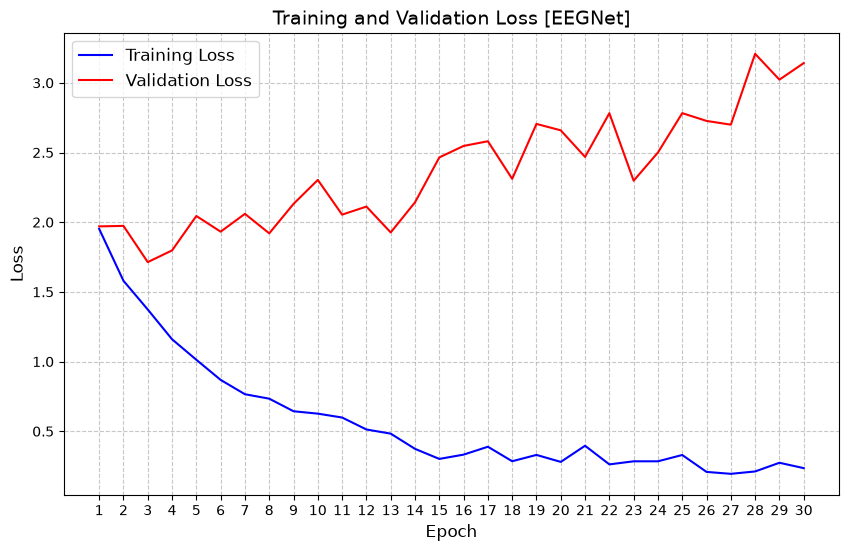

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

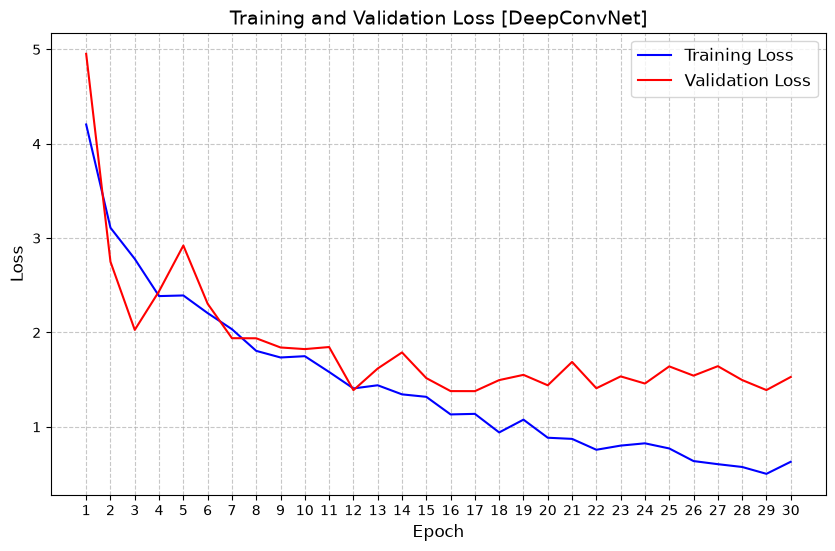

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

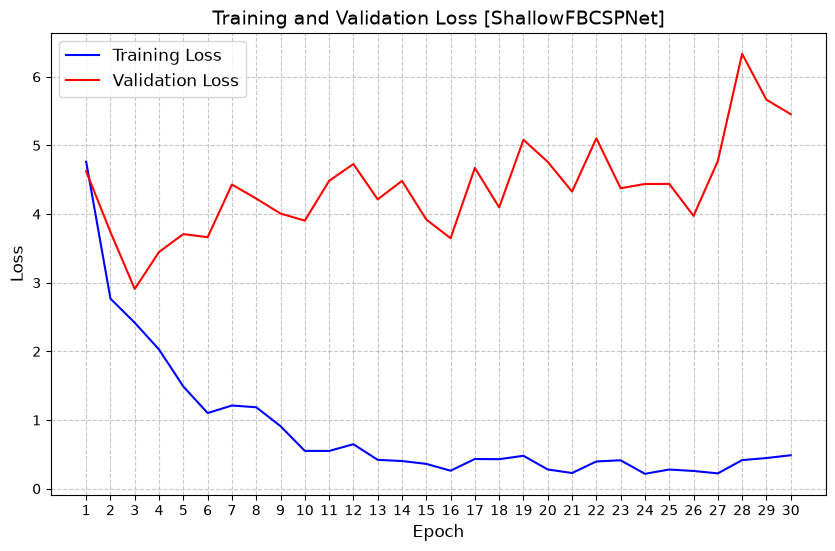

Finished training Subject 1.


In [5]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        print(f'Epoch#{epoch + 1} ====',
                f'train acc: {model.evaluate_accuracy(train_loader):.4f}, train loss: {t_loss:.4f} ====',
                f'val acc: {model.evaluate_accuracy(val_loader):.4f}, val loss: {v_loss:.4f}')
    print('Model Final Accuracy:')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")